In [1]:
# 第2章｜K 線型態全股票回測：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.


已登入（使用快取憑證）。

# K 線型態任意買賣點全股票回測

**對應影片**：第 2 章 單元 5「K 線型態任意買賣點全股票回測」

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| 自己用迴圈算持有部位、每日報酬、手續費，只測前 10 支股票 | `entries.hold_until(exits)` 產生部位，`sim()` 一次回測全部股票，手續費與交易稅自動計入 |
| 回測結果存成 pickle 給下一個單元用 | 下一個單元直接重新回測，不需要傳檔案 |

策略：

- **進場**：K 線型態出現，而且股票近 20 日平均成交量夠大。
- **出場**：收盤價跌破 20 日均線。
- **持股上限**：同時最多 `N_STOCKS` 檔；進場訊號太多時，優先買成交量大的股票。

In [2]:
import pandas as pd
from finlab.backtest import sim

BULLISH = 100
BEARISH = -100
N_STOCKS = 10
EXIT_MA_WINDOW = 20
LIQUIDITY_WINDOW = 20
MIN_AVG_VOLUME_SHARES = 500_000

close = data.get('price:收盤價')
volume = data.get('price:成交股數')
avg_volume = volume.average(LIQUIDITY_WINDOW)

## 1. 影片中的例子：三星十字（CDLTRISTAR）看漲訊號

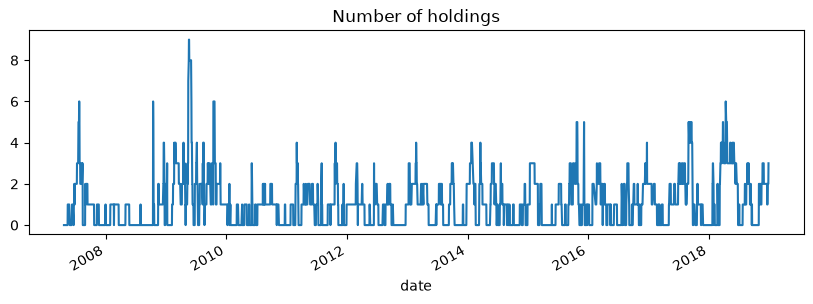

In [3]:
def pattern_position(pattern: str, direction: int) -> pd.DataFrame:
    """K 線型態出現就進場、跌破均線就出場的持股表。"""
    entries = (data.indicator(pattern) == direction) & (avg_volume > MIN_AVG_VOLUME_SHARES)
    exits = close < close.average(EXIT_MA_WINDOW)
    return entries.hold_until(exits, nstocks_limit=N_STOCKS, rank=avg_volume)


position = pattern_position('CDLTRISTAR', BULLISH)
position.sum(axis=1).plot(figsize=(10, 3), title='Number of holdings');

`sim()` 預設計入手續費 0.1425% 與證券交易稅 0.3%，而且以「訊號出現的下一個交易日」成交。

In [4]:
report = sim(position, name='CDLTRISTAR')
stats = report.get_stats()
print(f"年化報酬率 {stats['cagr']:.2%}，最大回檔 {stats['max_drawdown']:.2%}")

年化報酬率 -3.18%，最大回檔 -63.79%


每一筆交易的明細：

In [5]:
trades = report.get_trades()
trades[['entry_date', 'exit_date', 'return', 'period']].head(10)

,entry_date,exit_date,return,period
trade_index,,,,
0,2007-05-17,2007-05-29,-0.075080,8.0
1,2007-06-12,2007-06-21,-0.055840,5.0
2,2007-06-23,2007-06-27,-0.014070,3.0
3,2007-07-23,2007-07-27,-0.138283,4.0
4,2007-07-25,2007-07-30,-0.050028,3.0
5,2007-07-20,2007-07-30,-0.043756,6.0
6,2007-07-12,2007-08-01,0.035579,14.0
7,2007-06-29,2007-08-03,0.264035,25.0
8,2007-06-26,2007-08-13,0.818961,34.0


## 2. 任意型態都能回測

`pattern_position` 換一個型態名稱，就能回測另一種型態。

In [6]:
CANDIDATES = [
    ('CDLTRISTAR', BULLISH),
    ('CDLHARAMI', BULLISH),
    ('CDLENGULFING', BULLISH),
    ('CDLEVENINGSTAR', BEARISH),
    ('CDLHAMMER', BULLISH),
]


def summarize(report) -> dict:
    stats = report.get_stats()
    return {
        'CAGR': stats['cagr'],
        'Max drawdown': stats['max_drawdown'],
        'Sharpe': stats['daily_sharpe'],
        'Trades': len(report.get_trades()),
    }


reports = {
    f'{pattern} {direction}': sim(pattern_position(pattern, direction), name=pattern)
    for pattern, direction in CANDIDATES
}
summary = pd.DataFrame({name: summarize(r) for name, r in reports.items()}).T
summary.style.format({'CAGR': '{:.2%}', 'Max drawdown': '{:.2%}', 'Sharpe': '{:.2f}', 'Trades': '{:.0f}'})

,CAGR,Max drawdown,Sharpe,Trades
CDLTRISTAR 100,-3.18%,-63.79%,-0.07,315
CDLHARAMI 100,-21.52%,-95.52%,-0.90,2774
CDLENGULFING 100,-18.09%,-93.78%,-0.83,2301
CDLEVENINGSTAR -100,-16.64%,-92.03%,-0.60,2070
CDLHAMMER 100,-15.24%,-88.82%,-0.74,2742


和大盤（加權報酬指數，含股息）比較：

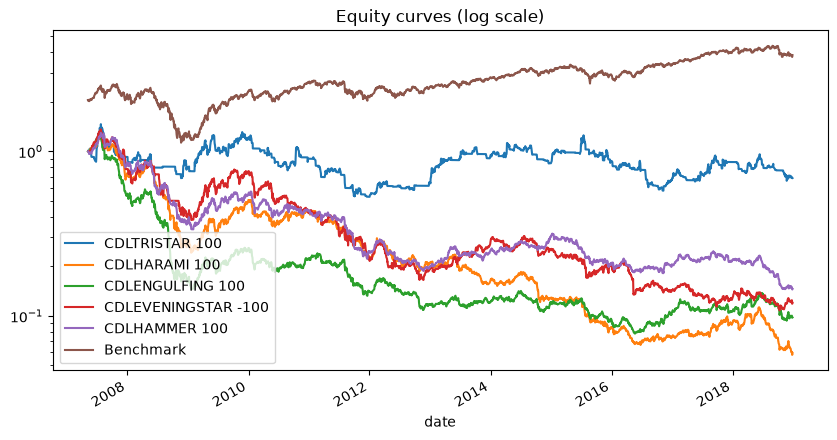

In [7]:
curves = pd.DataFrame({name: r.creturn for name, r in reports.items()})
curves['Benchmark'] = report.benchmark / report.benchmark.dropna().iloc[0]
curves.plot(figsize=(10, 5), logy=True, title='Equity curves (log scale)');

看看表格：扣掉手續費與交易稅之後，這些型態策略有沒有贏過大盤？交易次數越多，累積的交易成本越高。

試試看：

- 把上一個單元統計結果最好的型態放進 `CANDIDATES`，回測結果和統計一致嗎？
- 改變出場條件（例如 `EXIT_MA_WINDOW = 60`）或持股上限 `N_STOCKS`，結果差多少？

下一個單元用 Pyfolio 更完整地分析報酬曲線。